# Python club - week 2

This is the second of our python club problems. The aim of these tasks is to allow CCC colleagues to put their python skills to the test. We will hold a dedicated session for each problem to run through solutions and talk through difficulties that people may have encountered.

#### Task

Write a workflow which does the following:

- From ```./data/inputs```, reads in the following files:
    * ```cb7_hp_stock.csv```
    * ```high_carbon_heating_stock.csv``` 
    * Note: there may be some funny things going on with the data that you will need to fix

- Calculates the stock of each heating technology present in the baseline stock dataset out to 2050.
    * Assume that the total housing volume remains fixed.
    * Assume that heat pumps replace an equal proportion of all high carbon heating technologies.
    * Note: ```hp_stock.csv``` contains the CCC's CB7 pathway heat pump trajectory. This never reaches 100%, as there are other technologies available to decarbonise heating. However, for this exercise we will pretend that heat pumps are the only alternative, which means we will need to adjust the trajectory to reach a net zero housing stock.

- Plots the stock of each heating technology over time, using matplotlib.

- Additional questions to consider:

    * How would you model the problem if the housing stock did not remain fixed?
    * How would you model the problem assuming different rates of replacement for each baseline technology?
    * How would you model the problem if you were provided with market shares, not proportions of existing stock?

#### Example solution below

In [1]:
! pip install pandas
import pandas as pd
import numpy as np

In [2]:
# reading in the data

hp_df = pd.read_csv("./data/inputs/cb7_hp_stock.csv", skiprows=3)
high_carbon_df = pd.read_csv("./data/inputs/high_carbon_heating_stock.csv", skiprows=3)

In [3]:
# inspecting the data so we know what it looks like

hp_df.head()

,Year,Proportion of homes with a heat pump
0,2025,0.02
1,2026,0.02
2,2027,0.03
3,2028,0.03
4,2029,0.05


In [4]:
# see above

high_carbon_df.head()

,Heating system,Heating system type,Stock
0,Gas boiler,High carbon,22335759
1,Communal gas,High carbon,725329
2,Oil boiler,High carbon,1662917
3,Gas boiler (electric hot water),High carbon,5987
4,Gas other,High carbon,109618


As an optional first step, I'm choosing to clean up and rename some columns. This will make later operations easier to write.

In [5]:
# optional first step, cleaning up our column names

hp_df.columns = [c
                 .lower()
                 .replace(" ", "_") 
                 for c in hp_df.columns]

hp_df = hp_df.rename(columns={"proportion_of_homes_with_a_heat_pump" : "hp_proportion"})

high_carbon_df.columns = [c.lower().replace(" ", "_") for c in high_carbon_df.columns]

Now onto the actual calculation steps. We need to do transformations to each dataframe to get to our answer here:
- We need to get the proportion of stock for each heating system in our ```high_carbon_df```.
- We need to normalise the heat pump trajectory such that the end proportion = 1.

In [6]:
# calculating stock proportions

high_carbon_df["proportion_of_stock"] = high_carbon_df["stock"] / high_carbon_df["stock"].sum()

high_carbon_df

,heating_system,heating_system_type,stock,proportion_of_stock
0,Gas boiler,High carbon,22335759,0.878496
1,Communal gas,High carbon,725329,0.028528
2,Oil boiler,High carbon,1662917,0.065405
3,Gas boiler (electric hot water),High carbon,5987,0.000235
4,Gas other,High carbon,109618,0.004311
5,Gas other (electric hot water),High carbon,85720,0.003371
6,Solid fuel boiler,High carbon,499658,0.019652


In [7]:
# update the hp trajectory assuming the 2050 value = 100% and everything is adjusted up accordingly

normalisation_factor = 1 / hp_df["hp_proportion"].values[-1]

hp_df["hp_proportion"] *= normalisation_factor

hp_df

,year,hp_proportion
0,2025,0.0250
1,2026,0.0250
2,2027,0.0375
3,2028,0.0375
4,2029,0.0625
5,2030,0.0750
6,2031,0.1000
7,2032,0.1375
8,2033,0.2000
9,2034,0.2625


We've got proportion of stock by archetype now - the next step will be to turn this into a shape where we can calculate the curves to 2050.

Let's assume that the proportions stay fixed for the existing low carbon heating systems. This means we only need to worry about how the high carbon stocks decrease over time.

In [8]:
high_carbon_df = (high_carbon_df
                   .drop(columns=["heating_system_type", "stock"])
                   .assign(year=2023)
                   .pivot(columns="heating_system", values="proportion_of_stock", index="year")
                   )

high_carbon_df

heating_system,Communal gas,Gas boiler,Gas boiler (electric hot water),Gas other,Gas other (electric hot water),Oil boiler,Solid fuel boiler
year,,,,,,,
2023,0.028528,0.878496,0.000235,0.004311,0.003371,0.065405,0.019652


Let's now figure out how much this would need to decrease by in each case in each year.

All we need to do is work out how to split the increase in heat pump stock across the high carbon archetypes and we can proceed.

In [9]:
# doing some basic preparation of the dataframe

future_stock_df = hp_df.copy()
future_stock_df = future_stock_df.set_index("year")

In [10]:
# let's define the high carbon columns for ease

high_carbon_columns = high_carbon_df.columns.tolist()

In [11]:
# adding the high carbon columns to our dataframe

future_stock_df[high_carbon_columns] = np.nan

# iterating through each high carbon heating type
# then defining the start value
# then working out the value across the whole column based on the initial value and the proportion of heat pumps in stock

for col in high_carbon_columns:
    temp_start_value = high_carbon_df[col].values[0]
    future_stock_df[col] = (
                            temp_start_value 
                            - (temp_start_value * future_stock_df["hp_proportion"])
                            )

future_stock_df

,hp_proportion,Communal gas,Gas boiler,Gas boiler (electric hot water),Gas other,Gas other (electric hot water),Oil boiler,Solid fuel boiler
year,,,,,,,,
2025,0.0250,0.027815,0.856534,0.000230,0.004204,0.003287,0.063770,0.019161
2026,0.0250,0.027815,0.856534,0.000230,0.004204,0.003287,0.063770,0.019161
2027,0.0375,0.027458,0.845553,0.000227,0.004150,0.003245,0.062952,0.018915
2028,0.0375,0.027458,0.845553,0.000227,0.004150,0.003245,0.062952,0.018915
2029,0.0625,0.026745,0.823590,0.000221,0.004042,0.003161,0.061317,0.018424
2030,0.0750,0.026389,0.812609,0.000218,0.003988,0.003119,0.060499,0.018178
2031,0.1000,0.025675,0.790647,0.000212,0.003880,0.003034,0.058864,0.017687
2032,0.1375,0.024606,0.757703,0.000203,0.003719,0.002908,0.056412,0.016950
2033,0.2000,0.022823,0.702797,0.000188,0.003449,0.002697,0.052324,0.015722


In [12]:
full_df = future_stock_df.copy()
full_df = full_df.rename(columns={"proportion_of_homes_with_a_heat_pump" : "heat_pump"})

In [13]:
full_df.columns = [col
                   .lower()
                   .replace(" ", "_")
                   .replace("(","")
                   .replace(")","")
                   for col in full_df.columns]

full_df

,hp_proportion,communal_gas,gas_boiler,gas_boiler_electric_hot_water,gas_other,gas_other_electric_hot_water,oil_boiler,solid_fuel_boiler
year,,,,,,,,
2025,0.0250,0.027815,0.856534,0.000230,0.004204,0.003287,0.063770,0.019161
2026,0.0250,0.027815,0.856534,0.000230,0.004204,0.003287,0.063770,0.019161
2027,0.0375,0.027458,0.845553,0.000227,0.004150,0.003245,0.062952,0.018915
2028,0.0375,0.027458,0.845553,0.000227,0.004150,0.003245,0.062952,0.018915
2029,0.0625,0.026745,0.823590,0.000221,0.004042,0.003161,0.061317,0.018424
2030,0.0750,0.026389,0.812609,0.000218,0.003988,0.003119,0.060499,0.018178
2031,0.1000,0.025675,0.790647,0.000212,0.003880,0.003034,0.058864,0.017687
2032,0.1375,0.024606,0.757703,0.000203,0.003719,0.002908,0.056412,0.016950
2033,0.2000,0.022823,0.702797,0.000188,0.003449,0.002697,0.052324,0.015722


In [14]:
full_df.sum(axis=1)

year
2025    1.0
2026    1.0
2027    1.0
2028    1.0
2029    1.0
2030    1.0
2031    1.0
2032    1.0
2033    1.0
2034    1.0
2035    1.0
2036    1.0
2037    1.0
2038    1.0
2039    1.0
2040    1.0
2041    1.0
2042    1.0
2043    1.0
2044    1.0
2045    1.0
2046    1.0
2047    1.0
2048    1.0
2049    1.0
2050    1.0
dtype: float64

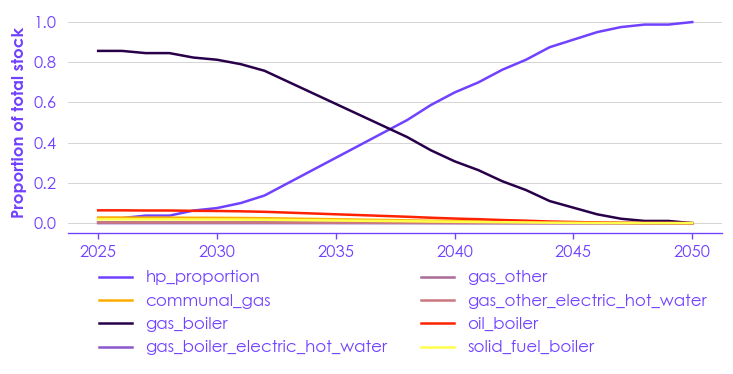

In [15]:
# and plotting the two together
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
sys.path.append(PROJECT_ROOT)

import matplotlib.pyplot as plt
from utils import theme

fig, axs = plt.subplots()

for col in future_stock_df.columns:
    axs.plot(future_stock_df[col])

axs.set_ylabel("Proportion of total stock")
axs.legend(full_df.columns,
           bbox_to_anchor=(1,-0.1),
           ncol=2)